# Things to Learn
- Pandas
    -  Multindex
    - GroupBy
    - String Splice, Split, joins
- Left,right,center joins
- seaborn
- visualization (Choropleth, etc)


## PANDAS
 - Merge Vs. Concat
 - Left Merge
 - Right Merge
 - df.drop
 - df.iloc
 - .unstack
 - .stack
 - .rename

SEABORN
- Import libs: Pandas, seaborn(sns)
- pull data (pd.read_...)
- check data (head(5))
- read columns and observations
- types of plots:
    - Distribution Plot (sns.displot x = ..., kind = ... , hue = ... ,fill = T/F)
        - Y axis will be the count of the items
        - kind shows the type of chart (kde: kernel density estimation)
        - hue colors the plot based on a certain variable.
    - Count Plot (sns.countplot(x = ... data = df, hue = ..., palette = ...))
    - Box Plot (sns.boxplot(x = "..." , " y = "..."))
        - Similarly, Violin Plot (sns.vilionplot())
        


    



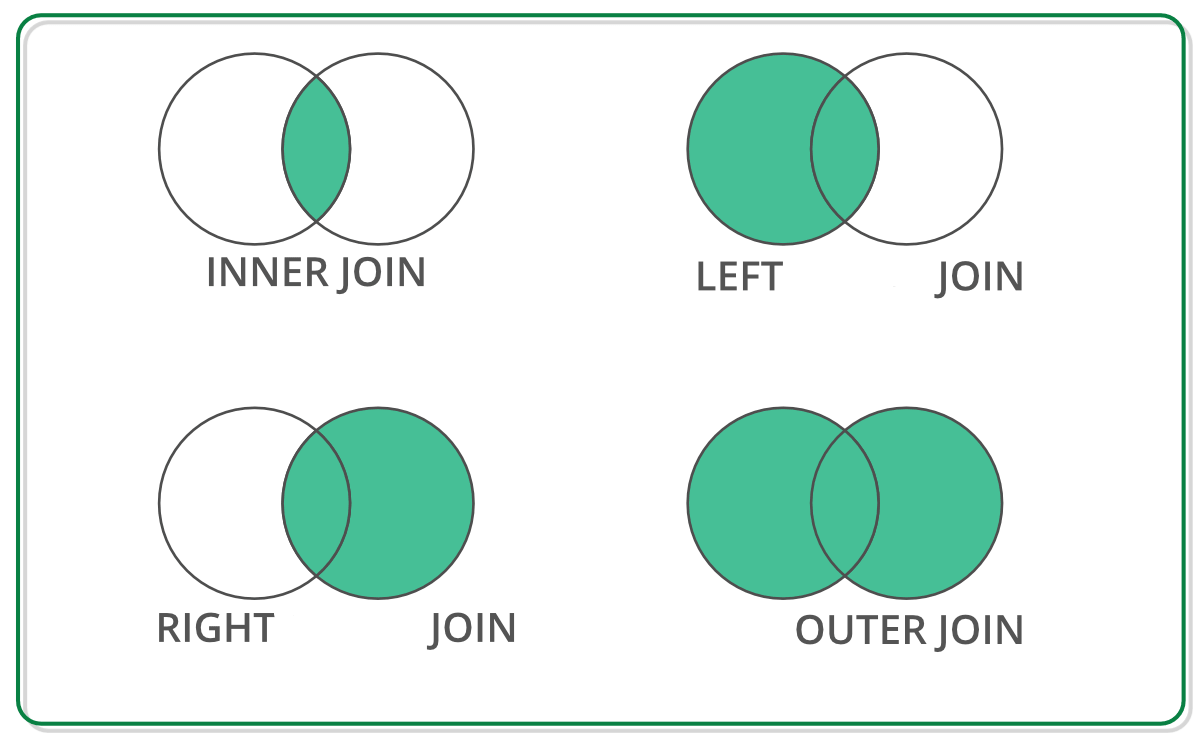

In [30]:
import pandas as pd
import os
os.chdir("/Users/jackson/Documents/ECON570")

In [31]:
df1 = pd.read_csv("data/nhe.csv")
df1.head()

,year,nhe
0,1960,27.1
1,1961,29.1
2,1962,31.8
3,1963,34.6
4,1964,38.2


In [44]:
df2 = pd.read_csv("data/nhe_cms.csv")
df2.head()

,year,nhe,consumption,personal,government,public_health,investment,population,gdp
0,1960,27.1,24.6,23.1,1.1,0.4,2.6,186,542.4
1,1961,29.1,26.2,24.6,1.2,0.4,2.9,189,562.2
2,1962,31.8,28.3,26.5,1.3,0.5,3.5,192,603.9
3,1963,34.6,30.8,29.0,1.3,0.5,3.8,195,637.5
4,1964,38.2,33.9,31.8,1.5,0.6,4.3,197,684.5


In [45]:
df2.merge(df1, how = 'left', on = ['year'])

,year,nhe_x,consumption,personal,government,public_health,investment,population,gdp,nhe_y
0,1960,27.1,24.6,23.1,1.1,0.4,2.6,186,542.4,27.1
1,1961,29.1,26.2,24.6,1.2,0.4,2.9,189,562.2,29.1
2,1962,31.8,28.3,26.5,1.3,0.5,3.5,192,603.9,31.8
3,1963,34.6,30.8,29.0,1.3,0.5,3.8,195,637.5,34.6
4,1964,38.2,33.9,31.8,1.5,0.6,4.3,197,684.5,38.2
...,...,...,...,...,...,...,...,...,...,...
57,2017,3446.5,3265.9,2903.8,266.6,95.5,180.6,325,19477.3,3446.5
58,2018,3604.4,3414.6,3019.8,295.4,99.4,189.9,327,20533.1,3604.4
59,2019,3757.4,3563.3,3173.1,283.2,107.1,194.1,328,21381.0,3757.4
60,2020,4144.1,3950.1,3367.0,344.9,238.3,193.9,329,21060.5,4144.1


In [36]:
df1.merge(df2 , how = 'right',  on=["year"])

,year,nhe_x,nhe_y,consumption,personal,government,public_health,investment,population,gdp
0,1960,27.1,27.1,24.6,23.1,1.1,0.4,2.6,186,542.4
1,1961,29.1,29.1,26.2,24.6,1.2,0.4,2.9,189,562.2
2,1962,31.8,31.8,28.3,26.5,1.3,0.5,3.5,192,603.9
3,1963,34.6,34.6,30.8,29.0,1.3,0.5,3.8,195,637.5
4,1964,38.2,38.2,33.9,31.8,1.5,0.6,4.3,197,684.5
...,...,...,...,...,...,...,...,...,...,...
57,2017,3446.5,3446.5,3265.9,2903.8,266.6,95.5,180.6,325,19477.3
58,2018,3604.4,3604.4,3414.6,3019.8,295.4,99.4,189.9,327,20533.1
59,2019,3757.4,3757.4,3563.3,3173.1,283.2,107.1,194.1,328,21381.0
60,2020,4144.1,4144.1,3950.1,3367.0,344.9,238.3,193.9,329,21060.5


### Notice how there is an nhe_x and nhe_y? That is because there are multiple of the same columns, and outer join will give both cloumns, even if they are the exact same. 
#### The join of observations is on the year

- Left Merge
    - All left + matching right
- Right Merge
    - All Right + Matching Left
- Inner
    - Only matching keys 
- Outer
    - All keys from both left + right
        - Fills blanks with NaN



### df.loc() and df.iloc()

| Method      | Selection Type     | Accepts       | Indexing Behavior                                 | Example        | Rows Returned   |
| ----------- | ------------------ | ------------- | ------------------------------------------------- | -------------- | --------------- |
| `df.iloc[]` | **Position-based** | Integers only | Python-style (start inclusive, end **exclusive**) | `df.iloc[0:3]` | Rows 0, 1, 2    |
| `df.loc[]`  | **Label-based**    | Labels only   | **Inclusive** of both start and end labels        | `df.loc[0:3]`  | Rows 0, 1, 2, 3 |


In [6]:
df1.iloc[0:3]
df2.iloc[0:10, 0:3]

,year,nhe,consumption
0,1960,27.1,24.6
1,1961,29.1,26.2
2,1962,31.8,28.3
3,1963,34.6,30.8
4,1964,38.2,33.9
5,1965,41.6,36.9
6,1966,45.8,40.8
7,1967,51.2,46.0
8,1968,58.0,52.2
9,1969,65.4,58.4


In [7]:
df2.loc[0:9,["consumption"]]

df2.loc[(df2.consumption > 300), ["gdp"]]

,gdp
22,3343.8
23,3634.0
24,4037.6
25,4339.0
26,4579.6
27,4855.2
28,5236.4
29,5641.6
30,5963.1
31,6158.1


## Regex

| Pattern | Meaning                                      | Example Match                                  |
| ------- | -------------------------------------------- | ---------------------------------------------- |
| `\w`    | Word character (letters, digits, underscore) | `A`, `z`, `5`, `_`                             |
| `\W`    | **Not** a word character                     | `#`, `!`, `-`                                  |
| `\d`    | Digit (0–9)                                  | `4`, `9`                                       |
| `\D`    | **Not** a digit                              | `a`, `!`                                       |
| `\s`    | Whitespace (space, tab, newline)             | `" "`, `\t`                                    |
| `\S`    | **Not** whitespace                           | `a`, `3`, `!`                                  |
| `.`     | Any character except newline                 | `a`, `9`, `!`                                  |
| `^`     | Start of string                              | `^Hello` matches "Hello there"                 |
| `$`     | End of string                                | `world$` matches "Hello world"                 |
| `\b`    | Word boundary                                | `\bcat\b` matches “cat” but not “scatter”      |
| `\B`    | **Not** a word boundary                      | `\Bcat\B` matches “concatenate” (inside words) |
_____

| Pattern  | Meaning                     | Example                                         |      |                          |
| -------- | --------------------------- | ----------------------------------------------- | ---- | ------------------------ |
| `[abc]`  | Any of a, b, or c           | Matches `a`, `b`, or `c`                        |      |                          |
| `[^abc]` | Any char **except** a, b, c | Matches `d`, `1`, etc.                          |      |                          |
| `(abc)`  | Group for capturing         | `(\d{3})-(\d{4})` captures area code and number |      |                          |
| `(a      | b)`                         | a **or** b                                      | `cat | dog` matches either word |



## Examples: import re
```python

re.findall(r"\b\w+\b", "This is a test")  
# → ['This', 'is', 'a', 'test']

re.findall(r"\d{3}-\d{4}", "Call 800-5555")  
# → ['800-5555']

re.findall(r"\bcat\b", "The cat sat on the scatter rug")  
# → ['cat']
```

In [17]:
del input

In [46]:
import re 
from os import system
pattern = r"[a-zA-Z0-9._%+-]+@[a-zA-Z.-]+\.(com|edu|org|net|co|gov)"

while True:
    user_input = input("Enter an email (or 'q' to quit): ").strip()
    if user_input.lower() == 'q':
        break

    if re.fullmatch(pattern, user_input):
        print(f" {user_input} is a valid email\n")
    else:
        print(f"{user_input} is an invalid email\n")

 jkaiman@wisc.edu is a valid email



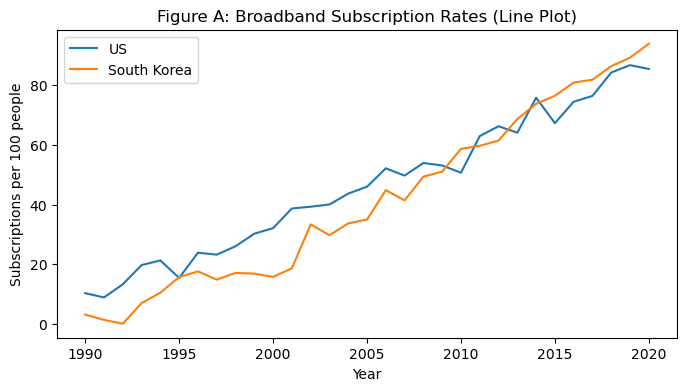

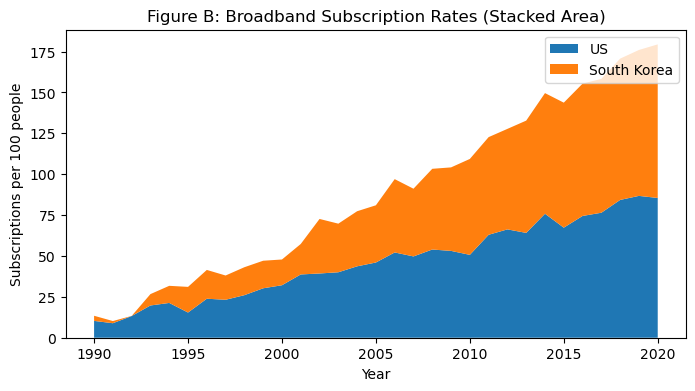

TypeError: choice() got an unexpected keyword argument 'cmap'

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------
# Q1.1  Broadband subscriptions
# -------------------------------

years = np.arange(1990, 2021)
us = np.linspace(5, 85, len(years)) + np.random.normal(0, 3, len(years))
sk = np.concatenate([
    np.linspace(2, 20, 10),
    np.linspace(20, 95, len(years)-10)
]) + np.random.normal(0, 3, len(years))

broadband = pd.DataFrame({'Year': years, 'US': us, 'South Korea': sk}).set_index('Year')

# Figure A – Line Plot
fig, ax = plt.subplots(figsize=(8, 4))
broadband.plot(ax=ax)
ax.set_title("Figure A: Broadband Subscription Rates (Line Plot)")
ax.set_ylabel("Subscriptions per 100 people")
ax.set_xlabel("Year")
ax.legend()
plt.show()

# Figure B – Stacked Area Plot
fig, ax = plt.subplots(figsize=(8, 4))
ax.stackplot(broadband.index, broadband['US'], broadband['South Korea'], labels=['US','South Korea'])
ax.set_title("Figure B: Broadband Subscription Rates (Stacked Area)")
ax.set_ylabel("Subscriptions per 100 people")
ax.set_xlabel("Year")
ax.legend()
plt.show()


# -------------------------------
# Q1.2  Crash distribution by lighting
# -------------------------------

np.random.seed(0)
lighting_conditions = np.random.choice(
    ['Daylight','Dark – lighted','Dark – not lighted','Dawn','Dusk'],
    size=5000,
    p=[0.5,0.25,0.15,0.05,0.05]
)
lighting_df = pd.DataFrame({'LightingCondition': lighting_conditions})

fig, ax = plt.subplots(figsize=(8,4))
sns.countplot(data=lighting_df, x='LightingCondition', color='steelblue', edgecolor='black', ax=ax)
ax.set_title("Figure C: Distribution of Crashes by Lighting Condition")
ax.set_xlabel("Lighting Condition")
ax.set_ylabel("Number of Crashes")
plt.xticks(rotation=30, ha='right')
plt.show()


# -------------------------------
# Q2  Debugging Visualization Examples
# (for illustration — not actual Q2 answers)
# -------------------------------

# Example choropleth debugging figure
# We'll use a built-in world dataset as a stand-in
world = sns.load_dataset('penguins')  # quick trick to avoid geopandas requirement
# Not actually used in Q2; debugging focuses on code errors, not visuals.
